<div class="jp-RenderedHTMLCommon jp-RenderedMarkdown jp-MarkdownOutput" data-mime-type="text/markdown">
<h1 id="NDVI-Change-and-Recovery-After-the-2017-Eagle-Creek-Fire-(2014%E2%80%932024)">NDVI Change and Recovery After the 2017 Eagle Creek Fire (2014–2024)</h1><p>The Eagle Creek Fire (2017) burned a large portion of the Columbia River Gorge in northern Oregon, affecting forest structure, recreation access, and viewsheds along the Interstate 84 corridor and the Historic Columbia River Highway. In this project, I use satellite-derived NDVI (Normalized Difference Vegetation Index) to quantify how vegetation greenness changed inside the fire perimeter and how it has recovered relative to nearby unburned areas.</p>
<p><strong>Research Question</strong></p>
<p>How did NDVI change inside the Eagle Creek Fire scar compared to surrounding unburned forests, and what does the NDVI trajectory suggest about vegetation recovery in the years following the fire?</p>
<p><strong>Objectives</strong></p>
<ol>
<li>Delineate the Eagle Creek Fire burn area using an MTBS (Monitoring Trends in Burn Severity) fire-perimeter polygon.</li>
<li>Derive annual NDVI metrics for a multiyear period before and after the fire (e.g., 2014–2024).</li>
<li>Compare NDVI trends inside the burn area to a nearby unburned “control” region.</li>
<li>Visualize both:<ul>
<li>A time series of NDVI inside vs. outside the burn.</li>
<li>A sequence of NDVI maps illustrating pre-fire conditions, immediate post-fire decline, and subsequent recovery.</li>
</ul>
</li>
</ol>
</div>

<div class="jp-RenderedHTMLCommon jp-RenderedMarkdown jp-MarkdownOutput" data-mime-type="text/markdown">
<h2 id="Background-and-Context">Background and Context</h2><p>The Eagle Creek Fire started in early September 2017 in the Columbia River Gorge, eventually burning thousands of acres of mixed conifer and broadleaf forest. The Gorge is a high-visibility landscape that supports hiking, tourism, and transportation, so changes in vegetation cover are both ecologically and socially important.</p>
<p>NDVI (Normalized Difference Vegetation Index) is a widely used remote-sensing metric that approximates vegetation vigor and canopy density. NDVI is defined as:</p>
<p>[
\text{NDVI} = \frac{NIR - Red}{NIR + Red}
]</p>
<p>where <em>NIR</em> is reflectance in a near-infrared band and <em>Red</em> is reflectance in a red band. Higher NDVI values generally indicate more photosynthetically active vegetation.</p>
<p>Post-fire recovery studies often use NDVI (or related indices) to:</p>
<ul>
<li>Quantify immediate loss of canopy cover after fire.</li>
<li>Track regrowth of shrubs, grasses, and trees over time.</li>
<li>Compare burn severity classes or burned vs. unburned reference areas.</li>
</ul>
<p>In this project, I focus on NDVI-based comparison of burned vs. unburned areas across multiple years, rather than detailed burn-severity classes, to keep the analysis reasonable.</p>
</div>

In [ ]:
# Install packages needed by this notebook in GeoLab
%pip install -q geopandas rioxarray hvplot osmnx requests

In [5]:
from __future__ import annotations

from collections import defaultdict
from getpass import getpass
from pathlib import Path
import time

import geopandas as gpd
import holoviews as hv
import hvplot.pandas
import hvplot.xarray
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import osmnx as ox
import pandas as pd
import requests
import rioxarray as rxr
import xarray as xr

hv.extension("bokeh")

# Plot and display settings
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = False
xr.set_options(display_style="text")


In [6]:
# Create a portable project structure relative to this notebook
PROJECT_DIR = Path("eagle_creek_ndvi")
DATA_DIR = PROJECT_DIR / "data"
NDVI_DIR = DATA_DIR / "ndvi"
FIRE_DIR = DATA_DIR / "fire_perimeter"
LANDSLIDE_DIR = DATA_DIR / "landslide_mapping"
OUTPUT_DIR = PROJECT_DIR / "outputs"

for directory in (NDVI_DIR, FIRE_DIR, LANDSLIDE_DIR, OUTPUT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR.resolve()}")
print(f"Fire perimeter files: {FIRE_DIR.resolve()}")
print(f"Landslide files: {LANDSLIDE_DIR.resolve()}")
print(f"NDVI downloads: {NDVI_DIR.resolve()}")


Project directory: /home/jovyan/eagle_creek_ndvi
Fire perimeter files: /home/jovyan/eagle_creek_ndvi/data/fire_perimeter
Landslide files: /home/jovyan/eagle_creek_ndvi/data/landslide_mapping
NDVI downloads: /home/jovyan/eagle_creek_ndvi/data/ndvi


In [7]:
import zipfile
import requests
import geopandas as gpd

zip_path = FIRE_DIR / "mtbs_perimeter_data.zip"

mtbs_url = (
    "https://edcintl.cr.usgs.gov/downloads/sciweb1/shared/"
    "MTBS_Fire/data/composite_data/"
    "burned_area_extent_shapefile/mtbs_perimeter_data.zip"
)

# Download the archive if it is not already present
if not zip_path.exists():
    response = requests.get(mtbs_url, timeout=120)
    response.raise_for_status()
    zip_path.write_bytes(response.content)

# Extract the archive if no shapefile is present yet
if not list(FIRE_DIR.rglob("*.shp")):
    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(FIRE_DIR)

# Find the extracted shapefile
fire_candidates = sorted(FIRE_DIR.rglob("*.shp"))

if not fire_candidates:
    raise FileNotFoundError(
        f"No shapefile was found after extracting {zip_path}"
    )

mtbs_path = fire_candidates[0]
mtbs_gdf = gpd.read_file(mtbs_path)

print(f"Loaded: {mtbs_path}")
print(f"Number of fire perimeters: {len(mtbs_gdf):,}")

Loaded: eagle_creek_ndvi/data/fire_perimeter/mtbs_perims_DD.shp
Number of fire perimeters: 30,613


In [8]:
# Locate the MTBS perimeter shapefile
fire_candidates = sorted(FIRE_DIR.rglob("*.shp"))

if not fire_candidates:
    raise FileNotFoundError(
        f"No MTBS shapefile found in {FIRE_DIR.resolve()}"
    )

mtbs_path = fire_candidates[0]
mtbs_gdf = gpd.read_file(mtbs_path)

# Find the fire-name column
name_column = next(
    col for col in mtbs_gdf.columns
    if col.lower() in {"incid_name", "fire_name", "incident", "name"}
)

# Select Eagle Creek
fire_gdf = mtbs_gdf[
    mtbs_gdf[name_column]
    .astype(str)
    .str.contains("Eagle Creek", case=False, na=False)
].copy()

# Dissolve into a single polygon if multiple features exist
fire_gdf = fire_gdf.dissolve().reset_index(drop=True)

print(f"Loaded {len(mtbs_gdf):,} fire perimeters")
print(f"Selected {len(fire_gdf)} Eagle Creek feature(s)")
fire_gdf


Loaded 30,613 fire perimeters
Selected 1 Eagle Creek feature(s)


,geometry,event_id,irwinid,incid_name,incid_type,map_id,map_prog,asmnt_type,burnbndac,burnbndlat,...,post_id,perim_id,dnbr_offst,dnbr_stddv,nodata_t,incgreen_t,low_t,mod_t,high_t,comment
0,"MULTIPOLYGON (((-122.06769 45.59501, -122.0675...",MT4544010660720120922,B942230F-938F-4584-93A0-D406F53284C6,EAGLE CREEK,Wildfire,1473,MTBS,Initial,4517.0,45.44850256151732,...,703602820121107,B12UWU20220927_30m,23.0,21.0,-970.0,-150.0,100,294,530,Eagle Creek and Eagle Creek 2 could not be dis...


<Axes: >

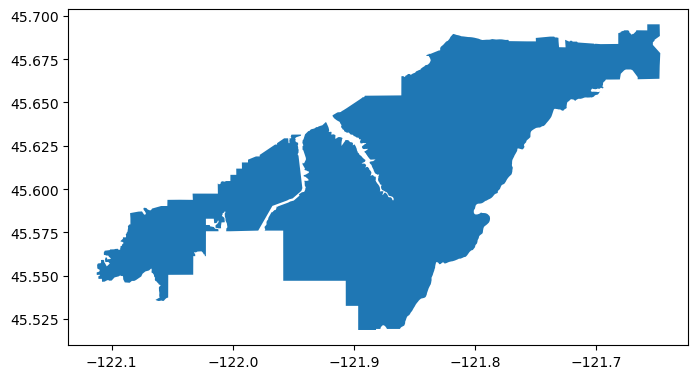

In [9]:
# Get a polygon for the analysis area from OpenStreetMap
hatfield_gdf = ox.geocode_to_gdf("Mark O. Hatfield Wilderness, Oregon, USA")

if hatfield_gdf.empty:
    raise RuntimeError("OpenStreetMap did not return the Hatfield Wilderness boundary.")

hatfield_gdf.plot()


In [10]:
# Years to analyze
pre_fire_years = list(range(2014, 2017))   # 2014, 2015, 2016
fire_year = 2017                           # fire start year
post_fire_years = list(range(2018, 2025))  # 2018–2024

all_years = pre_fire_years + [fire_year] + post_fire_years

all_years

[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

In [11]:
# Configure the current NASA AppEEARS REST API request
APPEEARS_API = "https://appeears.earthdatacloud.nasa.gov/api"
PRODUCT = "MOD13Q1.061"
LAYER = "_250m_16_days_NDVI"
TASK_NAME = "eagle-creek-ndvi-august-2014-2024"

# Create one August date range per year to reproduce the original recurring request
date_ranges = [
    {
        "startDate": f"08-01-{year}",
        "endDate": f"08-31-{year}",
    }
    for year in all_years
]

# AppEEARS area requests require a GeoJSON feature collection in geographic coordinates
request_polygon = hatfield_gdf.to_crs("EPSG:4326").__geo_interface__

task_payload = {
    "task_type": "area",
    "task_name": TASK_NAME,
    "params": {
        "dates": date_ranges,
        "layers": [{"product": PRODUCT, "layer": LAYER}],
        "output": {
            "format": {"type": "geotiff"},
            "projection": "geographic",
        },
        "geo": request_polygon,
    },
}

print(f"Prepared {len(date_ranges)} August date ranges.")


Prepared 11 August date ranges.


Create an account at https://urs.earthdata.nasa.gov/

In [12]:
def appeears_login() -> str:
    """Authenticate with AppEEARS and return a temporary access token."""
    username = input("NASA Earthdata username: ").strip()
    password = getpass("NASA Earthdata password: ")

    response = requests.post(
        f"{APPEEARS_API}/login",
        auth=(username, password),
        timeout=60,
    )
    response.raise_for_status()

    token = response.json().get("token")
    if not token:
        raise RuntimeError("AppEEARS authentication succeeded but returned no token.")
    return token


def submit_appeears_task(token: str, payload: dict) -> str:
    """Submit an AppEEARS area task and return its task ID."""
    response = requests.post(
        f"{APPEEARS_API}/task",
        headers={"Authorization": f"Bearer {token}"},
        json=payload,
        timeout=120,
    )
    response.raise_for_status()

    task_id = response.json().get("task_id")
    if not task_id:
        raise RuntimeError(f"AppEEARS returned no task ID: {response.text}")
    return task_id


def wait_for_appeears_task(
    token: str,
    task_id: str,
    poll_seconds: int = 20,
) -> dict:
    """Poll AppEEARS until a task finishes or fails."""
    while True:
        response = requests.get(
            f"{APPEEARS_API}/task/{task_id}",
            headers={"Authorization": f"Bearer {token}"},
            timeout=60,
        )
        response.raise_for_status()
        status_info = response.json()
        status = str(status_info.get("status", "")).lower()
        print(f"AppEEARS task status: {status}")

        if status in {"done", "success", "completed"}:
            return status_info
        if status in {"error", "failed", "cancelled", "canceled"}:
            raise RuntimeError(f"AppEEARS task failed: {status_info}")

        time.sleep(poll_seconds)


def download_appeears_bundle(token: str, task_id: str, destination: Path) -> list[Path]:
    """Download every file in a completed AppEEARS task bundle."""
    destination.mkdir(parents=True, exist_ok=True)

    response = requests.get(
        f"{APPEEARS_API}/bundle/{task_id}",
        headers={"Authorization": f"Bearer {token}"},
        timeout=120,
    )
    response.raise_for_status()
    bundle = response.json()

    files = bundle.get("files", bundle if isinstance(bundle, list) else [])
    downloaded = []

    for item in files:
        file_id = item.get("file_id")
        file_name = item.get("file_name") or item.get("filename")
        if not file_id or not file_name:
            continue

        output_path = destination / Path(file_name).name
        if output_path.exists() and output_path.stat().st_size > 0:
            downloaded.append(output_path)
            continue

        with requests.get(
            f"{APPEEARS_API}/bundle/{task_id}/{file_id}",
            headers={"Authorization": f"Bearer {token}"},
            stream=True,
            timeout=300,
        ) as file_response:
            file_response.raise_for_status()
            with output_path.open("wb") as output_file:
                for chunk in file_response.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        output_file.write(chunk)

        downloaded.append(output_path)
        print(f"Downloaded: {output_path.name}")

    return downloaded


# Reuse existing downloads when present; otherwise request them from AppEEARS
existing_ndvi = sorted(NDVI_DIR.rglob("*NDVI*.tif"))

if existing_ndvi:
    print(f"Found {len(existing_ndvi)} existing NDVI files; skipping download.")
else:
    token = appeears_login()
    task_id = submit_appeears_task(token, task_payload)
    print(f"Submitted AppEEARS task: {task_id}")
    wait_for_appeears_task(token, task_id)
    downloaded_files = download_appeears_bundle(token, task_id, NDVI_DIR)
    print(f"Downloaded {len(downloaded_files)} bundle files.")


Found 33 existing NDVI files; skipping download.


In [13]:
# Get a sorted list of downloaded NDVI GeoTIFFs
ndvi_paths = sorted(NDVI_DIR.rglob("*NDVI*.tif"))

if not ndvi_paths:
    raise FileNotFoundError(
        "No NDVI GeoTIFFs were found after the AppEEARS download. "
        f"Check the task results and the folder: {NDVI_DIR.resolve()}"
    )

print(f"Found {len(ndvi_paths)} NDVI files.")
ndvi_paths[:5]


Found 33 NDVI files.


[PosixPath('eagle_creek_ndvi/data/ndvi/MOD13Q1.061__250m_16_days_NDVI_doy2014209000000_aid0001.tif'),
 PosixPath('eagle_creek_ndvi/data/ndvi/MOD13Q1.061__250m_16_days_NDVI_doy2014225000000_aid0001.tif'),
 PosixPath('eagle_creek_ndvi/data/ndvi/MOD13Q1.061__250m_16_days_NDVI_doy2014241000000_aid0001.tif'),
 PosixPath('eagle_creek_ndvi/data/ndvi/MOD13Q1.061__250m_16_days_NDVI_doy2015209000000_aid0001.tif'),
 PosixPath('eagle_creek_ndvi/data/ndvi/MOD13Q1.061__250m_16_days_NDVI_doy2015225000000_aid0001.tif')]

In [14]:
# Group MODIS NDVI files by year using the doyYYYY portion of each filename
paths_by_year = defaultdict(list)

for path in ndvi_paths:
    match = __import__("re").search(r"doy(\d{4})", path.name)
    if match:
        paths_by_year[int(match.group(1))].append(path)

if not paths_by_year:
    raise ValueError("Could not identify years from the downloaded NDVI filenames.")

for year in sorted(paths_by_year):
    print(year, "->", len(paths_by_year[year]), "files")


2014 -> 3 files
2015 -> 3 files
2016 -> 3 files
2017 -> 3 files
2018 -> 3 files
2019 -> 3 files
2020 -> 3 files
2021 -> 3 files
2022 -> 3 files
2023 -> 3 files
2024 -> 3 files


In [15]:
#Build inside-fire and outside-ring polygons
# Use a projected CRS for buffering in meters
projected_crs = "EPSG:5070"   

# Reproject the fire perimeter
fire_proj = fire_gdf.to_crs(projected_crs)

# Dissolve to a single polygon (in case there are multiple pieces)
burn_geom = fire_proj.geometry.union_all()

# Make a ring around the fire: buffer outward, then subtract inside
buffer_distance = 3000  # 3 km ring
outer_buffer = burn_geom.buffer(buffer_distance)
outside_ring_geom = outer_buffer.difference(burn_geom)

# Turn those geometries back into GeoDataFrames
inside_gdf_proj = gpd.GeoDataFrame(
    {"region": ["inside_burn"], "geometry": [burn_geom]},
    crs=projected_crs,
)

outside_gdf_proj = gpd.GeoDataFrame(
    {"region": ["outside_burn"], "geometry": [outside_ring_geom]},
    crs=projected_crs,
)

In [16]:
# Inspect NDVI values to determine whether the GeoTIFFs contain scaled integers
test = rxr.open_rasterio(ndvi_paths[0], masked=True).squeeze("band", drop=True)

print("Min:", float(test.min(skipna=True).values))
print("Max:", float(test.max(skipna=True).values))
print("NoData:", test.rio.nodata)


Min: 4472.0
Max: 9121.0
NoData: nan


In [17]:
def load_ndvi_for_year(year: int) -> xr.DataArray:
    """Load a maximum-value August NDVI composite for one year."""
    if year not in paths_by_year:
        raise ValueError(f"No NDVI files found for year {year}")

    arrays = [
        rxr.open_rasterio(path, masked=True).squeeze("band", drop=True)
        for path in sorted(paths_by_year[year])
    ]

    ndvi_da = arrays[0] if len(arrays) == 1 else xr.concat(arrays, dim="time").max(
        dim="time",
        skipna=True,
    )
    ndvi_da = ndvi_da.astype("float32")

    # MOD13Q1 NDVI is commonly stored as an integer with a 0.0001 scale factor.
    # Some AppEEARS outputs may already apply that scale.
    max_value = float(ndvi_da.max(skipna=True).values)
    if max_value > 2:
        ndvi_da = ndvi_da * 0.0001

    ndvi_da.name = "NDVI"
    return ndvi_da


In [18]:
# Compute mean NDVI inside vs outside for each year
def summarize_ndvi_for_year(year: int):
    """
    For a given year:
      - load the NDVI composite
      - clip to inside and outside fire regions
      - return mean NDVI in each region
    """
    ndvi_da = load_ndvi_for_year(year)

    if ndvi_da.rio.crs is None:
        raise ValueError("NDVI raster has no CRS; please check your file.")

    # Reproject polygons to match NDVI CRS
    inside_for_clip = inside_gdf_proj.to_crs(ndvi_da.rio.crs)
    outside_for_clip = outside_gdf_proj.to_crs(ndvi_da.rio.crs)

    # Clip NDVI to each region
    ndvi_inside = ndvi_da.rio.clip(
        inside_for_clip.geometry,
        inside_for_clip.crs,
        drop=True,
        all_touched=True
    )

    ndvi_outside = ndvi_da.rio.clip(
        outside_for_clip.geometry,
        outside_for_clip.crs,
        drop=True,
        all_touched=True
    )

    # Flatten and drop NaNs
    inside_vals = ndvi_inside.values.ravel()
    outside_vals = ndvi_outside.values.ravel()

    inside_vals = inside_vals[~np.isnan(inside_vals)]
    outside_vals = outside_vals[~np.isnan(outside_vals)]

    return {
        "year": year,
        "ndvi_inside_mean": float(inside_vals.mean()) if inside_vals.size > 0 else np.nan,
        "ndvi_outside_mean": float(outside_vals.mean()) if outside_vals.size > 0 else np.nan,
    }

In [19]:
# Loop over all years
results = []

for yr in sorted(paths_by_year.keys()):
    print(f"Summarizing NDVI for year {yr}...")
    res = summarize_ndvi_for_year(yr)
    results.append(res)

ndvi_summary = pd.DataFrame(results).set_index("year").sort_index()
ndvi_summary

Summarizing NDVI for year 2014...
Summarizing NDVI for year 2015...
Summarizing NDVI for year 2016...
Summarizing NDVI for year 2017...
Summarizing NDVI for year 2018...
Summarizing NDVI for year 2019...
Summarizing NDVI for year 2020...
Summarizing NDVI for year 2021...
Summarizing NDVI for year 2022...
Summarizing NDVI for year 2023...
Summarizing NDVI for year 2024...


,ndvi_inside_mean,ndvi_outside_mean
year,,
2014,0.884826,0.865640
2015,0.872946,0.861016
2016,0.864685,0.854444
2017,0.862048,0.852591
2018,0.589486,0.823644
2019,0.652088,0.851156
2020,0.690972,0.843486
2021,0.681622,0.859721
2022,0.723242,0.842031


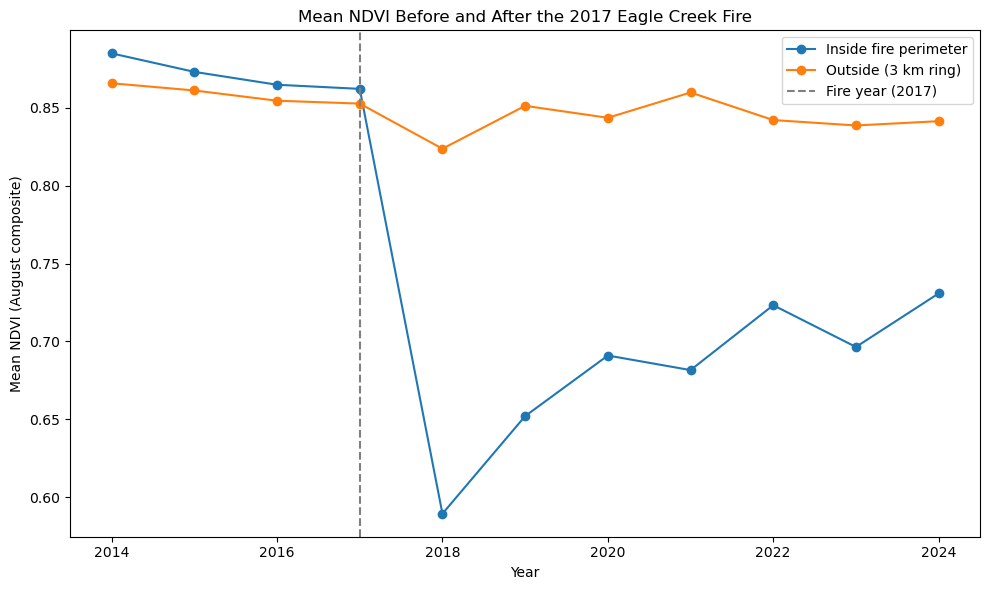

In [20]:
# Plot NDVI before and after the fire
fire_year = 2017  # Eagle Creek Fire year

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    ndvi_summary.index,
    ndvi_summary["ndvi_inside_mean"],
    marker="o",
    label="Inside fire perimeter",
)
ax.plot(
    ndvi_summary.index,
    ndvi_summary["ndvi_outside_mean"],
    marker="o",
    label="Outside (3 km ring)",
)

# Mark the fire year with a vertical line
ax.axvline(fire_year, linestyle="--", linewidth=1.5, color="gray", label="Fire year (2017)")

ax.set_xlabel("Year")
ax.set_ylabel("Mean NDVI (August composite)")
ax.set_title("Mean NDVI Before and After the 2017 Eagle Creek Fire")
ax.legend()
plt.tight_layout()
plt.show()

2016 NDVI: EPSG:4326 (86, 224)
2018 NDVI: EPSG:4326 (86, 224)
Clipped 2016 NDVI: (86, 224)
Clipped 2018 NDVI: (86, 224)
NDVI diff stats: min = -0.6520999670028687 max = 0.06540000438690186


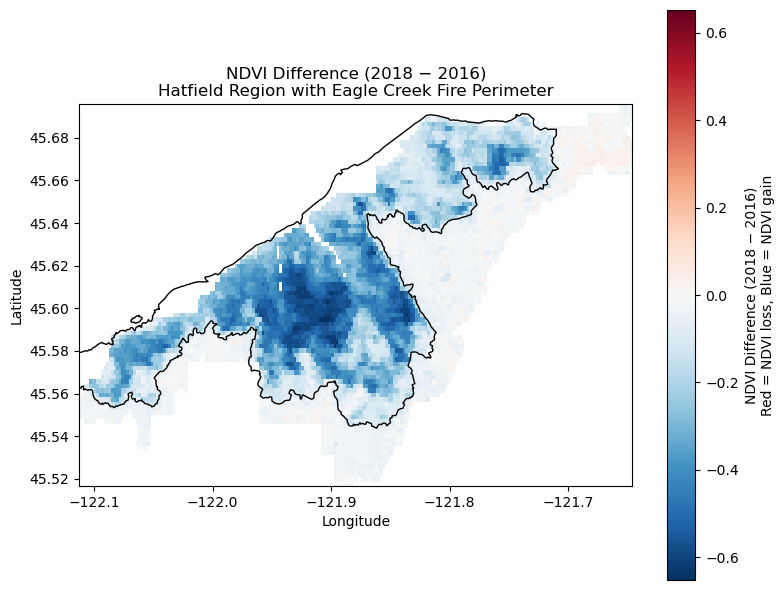

In [21]:
# NDVI Difference image 2018 - 2016 over the Hatfield polygon
# Load yearly NDVI composites
ndvi_2016 = load_ndvi_for_year(2016)
ndvi_2018 = load_ndvi_for_year(2018)

print("2016 NDVI:", ndvi_2016.rio.crs, ndvi_2016.shape)
print("2018 NDVI:", ndvi_2018.rio.crs, ndvi_2018.shape)

# Reproject 2018 NDVI to exactly match 2016 grid if needed
if (ndvi_2018.rio.crs != ndvi_2016.rio.crs) or (
    ndvi_2018.rio.resolution() != ndvi_2016.rio.resolution()
):
    ndvi_2018 = ndvi_2018.rio.reproject_match(ndvi_2016)

# Reproject Hatfield to NDVI CRS
hatfield_ndvi = hatfield_gdf.to_crs(ndvi_2016.rio.crs)

# Clip NDVI to Hatfield AOI
ndvi_2016_hat = ndvi_2016.rio.clip(
    hatfield_ndvi.geometry,
    hatfield_ndvi.crs,
    drop=True,
    all_touched=True
)

ndvi_2018_hat = ndvi_2018.rio.clip(
    hatfield_ndvi.geometry,
    hatfield_ndvi.crs,
    drop=True,
    all_touched=True
)

print("Clipped 2016 NDVI:", ndvi_2016_hat.shape)
print("Clipped 2018 NDVI:", ndvi_2018_hat.shape)  

# Difference: positive = greener in 2018, negative = loss of greenness
ndvi_diff = ndvi_2018_hat - ndvi_2016_hat

print(
    "NDVI diff stats:",
    "min =", float(np.nanmin(ndvi_diff.values)),
    "max =", float(np.nanmax(ndvi_diff.values))
)

# Symmetric color limits around 0 so gains/losses are visually balanced
max_abs = float(np.nanmax(np.abs(ndvi_diff.values)))
vlim = max_abs if max_abs > 0 else 0.5  # fallback if weird

fig, ax = plt.subplots(figsize=(8, 6))

im = ndvi_diff.plot(
    ax=ax,
    cmap="RdBu_r",      # red = loss, blue = gain 
    vmin=-vlim,
    vmax=vlim,
    add_colorbar=True
)

# Overlay fire perimeter
fire_ndvi = fire_gdf.to_crs(ndvi_2016.rio.crs)
fire_ndvi.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

ax.set_title("NDVI Difference (2018 − 2016)\nHatfield Region with Eagle Creek Fire Perimeter")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Colorbar label
cbar = im.colorbar
cbar.set_label("NDVI Difference (2018 − 2016)\nRed = NDVI loss, Blue = NDVI gain")

plt.tight_layout()
plt.show()

NDVI diff (2024–2016): min = -0.40890002250671387 max = 0.22759997844696045


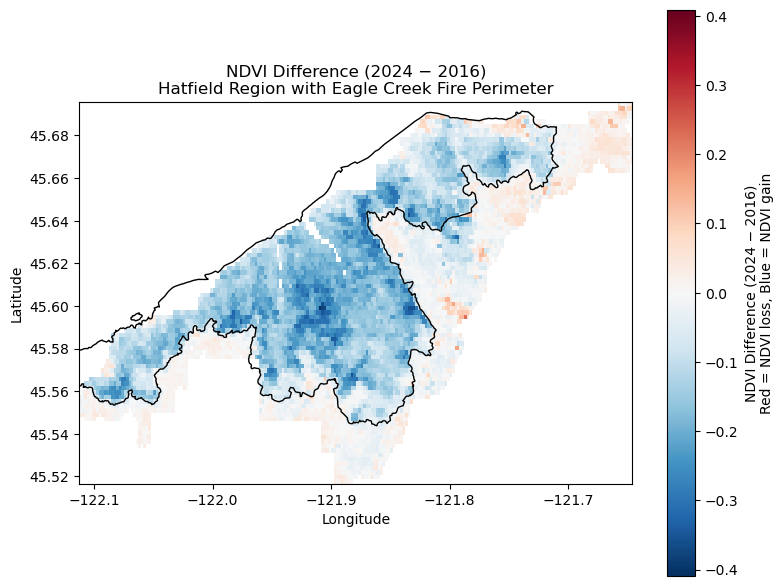

In [22]:
# 2024 - 2016  How much has the area recovered (seven years later)

# 1. Load composites
ndvi_2016 = load_ndvi_for_year(2016)
ndvi_2024 = load_ndvi_for_year(2024)

# 2. Ensure same grid
if (ndvi_2024.rio.crs != ndvi_2016.rio.crs) or (
    ndvi_2024.rio.resolution() != ndvi_2016.rio.resolution()
):
    ndvi_2024 = ndvi_2024.rio.reproject_match(ndvi_2016)

# 3. Clip both to Hatfield AOI
hatfield_ndvi = hatfield_gdf.to_crs(ndvi_2016.rio.crs)

ndvi_2016_hat = ndvi_2016.rio.clip(
    hatfield_ndvi.geometry, hatfield_ndvi.crs,
    drop=True, all_touched=True
)
ndvi_2024_hat = ndvi_2024.rio.clip(
    hatfield_ndvi.geometry, hatfield_ndvi.crs,
    drop=True, all_touched=True
)

# 4. Difference = 2024 – 2016
ndvi_diff_24_16 = ndvi_2024_hat - ndvi_2016_hat

print(
    "NDVI diff (2024–2016):",
    "min =", float(np.nanmin(ndvi_diff_24_16.values)),
    "max =", float(np.nanmax(ndvi_diff_24_16.values))
)

# 5. Plot using ORIGINAL orientation: RdBu (blue = negative, red = positive)
max_abs = float(np.nanmax(np.abs(ndvi_diff_24_16.values)))
vlim = max_abs if max_abs > 0 else 0.5

fig, ax = plt.subplots(figsize=(8, 6))

im = ndvi_diff_24_16.plot(
    ax=ax,
    cmap="RdBu_r",     # <<-- same as your first map
    vmin=-vlim,
    vmax=vlim,
    add_colorbar=True
)

# Fire perimeter
fire_ndvi = fire_gdf.to_crs(ndvi_2016.rio.crs)
fire_ndvi.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

ax.set_title("NDVI Difference (2024 − 2016)\nHatfield Region with Eagle Creek Fire Perimeter")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Colorbar label
cbar = im.colorbar
cbar.set_label("NDVI Difference (2024 − 2016)\nRed = NDVI loss, Blue = NDVI gain")

plt.tight_layout()
plt.show()

NDVI diff (2024–2018): min = -0.3005000352859497 max = 0.432699978351593


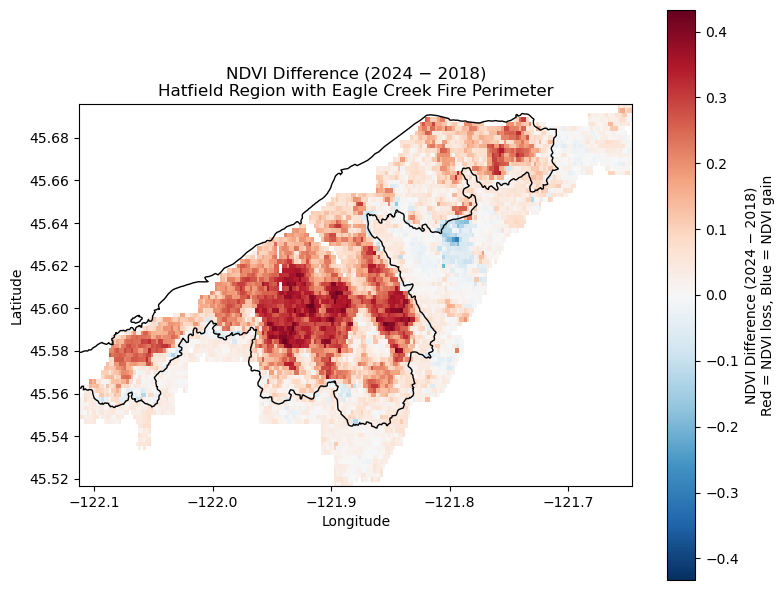

In [23]:
# 2024 - 2018  How much has the area recovered since the fire.

# 1. Load composites
ndvi_2018 = load_ndvi_for_year(2018)
ndvi_2024 = load_ndvi_for_year(2024)

# 2. Ensure same grid
if (ndvi_2024.rio.crs != ndvi_2018.rio.crs) or (
    ndvi_2024.rio.resolution() != ndvi_2018.rio.resolution()
):
    ndvi_2024 = ndvi_2024.rio.reproject_match(ndvi_2018)

# 3. Clip both to Hatfield AOI
hatfield_ndvi = hatfield_gdf.to_crs(ndvi_2018.rio.crs)

ndvi_2018_hat = ndvi_2018.rio.clip(
    hatfield_ndvi.geometry, hatfield_ndvi.crs,
    drop=True, all_touched=True
)
ndvi_2024_hat = ndvi_2024.rio.clip(
    hatfield_ndvi.geometry, hatfield_ndvi.crs,
    drop=True, all_touched=True
)

# 4. Difference = 2024 – 2018
ndvi_diff_24_18 = ndvi_2024_hat - ndvi_2018_hat

print(
    "NDVI diff (2024–2018):",
    "min =", float(np.nanmin(ndvi_diff_24_18.values)),
    "max =", float(np.nanmax(ndvi_diff_24_18.values))
)

# 5. Plot using ORIGINAL orientation: RdBu (blue = negative, red = positive)
max_abs = float(np.nanmax(np.abs(ndvi_diff_24_18.values)))
vlim = max_abs if max_abs > 0 else 0.5

fig, ax = plt.subplots(figsize=(8, 6))

im = ndvi_diff_24_18.plot(
    ax=ax,
    cmap="RdBu_r",     
    vmin=-vlim,
    vmax=vlim,
    add_colorbar=True
)

# Fire perimeter
fire_ndvi = fire_gdf.to_crs(ndvi_2018.rio.crs)
fire_ndvi.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

ax.set_title("NDVI Difference (2024 − 2018)\nHatfield Region with Eagle Creek Fire Perimeter")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Colorbar label
cbar = im.colorbar
cbar.set_label("NDVI Difference (2024 − 2018)\nRed = NDVI loss, Blue = NDVI gain")

plt.tight_layout()
plt.show()

2016: (86, 224) EPSG:4326
2018: (86, 224) EPSG:4326
2024: (86, 224) EPSG:4326
Clipped shapes: (71, 194) (71, 194) (71, 194)
Recovery stats (ignoring NaN):
  min: -1.8938469
  5th, 50th, 95th percentiles: [-0.05249886  0.51251     0.84866836]


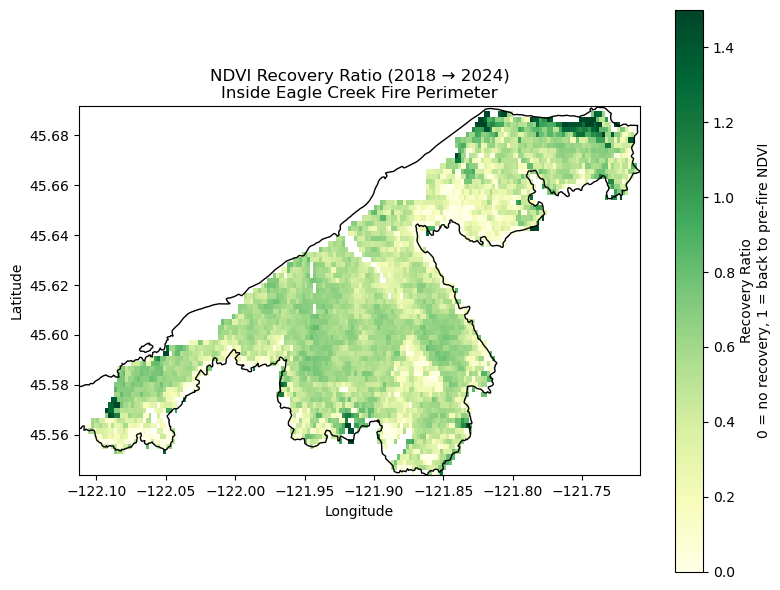

In [24]:
# Recovery Trajectory Map Inside the Fire Perimeter

# 1. Load NDVI composites for key years
ndvi_2016 = load_ndvi_for_year(2016)
ndvi_2018 = load_ndvi_for_year(2018)
ndvi_2024 = load_ndvi_for_year(2024)

# 2. Make sure they share the same grid / CRS
# (AppEEARS usually ensures this, but let's be safe)
if (ndvi_2018.rio.crs != ndvi_2016.rio.crs) or (
    ndvi_2018.rio.resolution() != ndvi_2016.rio.resolution()
):
    ndvi_2018 = ndvi_2018.rio.reproject_match(ndvi_2016)

if (ndvi_2024.rio.crs != ndvi_2016.rio.crs) or (
    ndvi_2024.rio.resolution() != ndvi_2016.rio.resolution()
):
    ndvi_2024 = ndvi_2024.rio.reproject_match(ndvi_2016)

print("2016:", ndvi_2016.shape, ndvi_2016.rio.crs)
print("2018:", ndvi_2018.shape, ndvi_2018.rio.crs)
print("2024:", ndvi_2024.shape, ndvi_2024.rio.crs)

# 3. Clip all three rasters to the *fire perimeter* only
fire_ndvi = fire_gdf.to_crs(ndvi_2016.rio.crs)

ndvi_2016_fire = ndvi_2016.rio.clip(
    fire_ndvi.geometry, fire_ndvi.crs,
    drop=True, all_touched=True
)
ndvi_2018_fire = ndvi_2018.rio.clip(
    fire_ndvi.geometry, fire_ndvi.crs,
    drop=True, all_touched=True
)
ndvi_2024_fire = ndvi_2024.rio.clip(
    fire_ndvi.geometry, fire_ndvi.crs,
    drop=True, all_touched=True
)

print("Clipped shapes:", ndvi_2016_fire.shape, ndvi_2018_fire.shape, ndvi_2024_fire.shape)

# 4. Compute pre- and post-fire changes relative to 2018
# (we expect 2016 > 2018 inside the burn)
pre_loss = ndvi_2016_fire - ndvi_2018_fire     # how much NDVI was lost
post_gain = ndvi_2024_fire - ndvi_2018_fire    # how much NDVI has come back

# 5. Build recovery ratio:
#    0   -> no recovery
#    1   -> fully back to pre-fire NDVI
#   >1   -> above pre-fire NDVI
#
# Guard against divide-by-zero or tiny pre-loss values (unburned / unchanged pixels)
pre_loss_vals = pre_loss.values
post_gain_vals = post_gain.values

recovery = np.full_like(pre_loss_vals, np.nan, dtype="float32")

# Define a minimum NDVI loss to consider "burned"
loss_threshold = 0.05  # NDVI units

valid_mask = np.abs(pre_loss_vals) > loss_threshold

recovery[valid_mask] = post_gain_vals[valid_mask] / pre_loss_vals[valid_mask]

# Wrap back into a DataArray with spatial metadata
recovery_da = ndvi_2016_fire.copy(data=recovery)
recovery_da.name = "ndvi_recovery_ratio"

print("Recovery stats (ignoring NaN):")
print("  min:", np.nanmin(recovery))
print("  5th, 50th, 95th percentiles:",
      np.nanpercentile(recovery, [5, 50, 95]))

# 6. For plotting, clip extreme values to a reasonable range
#    (e.g., 0 to 1.5, where 1.0 = full recovery)
recovery_plot = recovery_da.clip(0, 1.5)

fig, ax = plt.subplots(figsize=(8, 6))

im = recovery_plot.plot(
    ax=ax,
    cmap="YlGn",          # sequential: pale = low recovery, dark = strong recovery
    vmin=0,
    vmax=1.5,
    add_colorbar=True
)

# Overlay fire perimeter outline
fire_ndvi.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

ax.set_title("NDVI Recovery Ratio (2018 → 2024)\nInside Eagle Creek Fire Perimeter")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

cbar = im.colorbar
cbar.set_label("Recovery Ratio\n0 = no recovery, 1 = back to pre-fire NDVI")

plt.tight_layout()
plt.show()